In [ ]:
%pip install puremacro


# Un choque, seis identificaciones

**¿Qué le pasa a la producción industrial de EE.UU. tras un choque de
incertidumbre?** Bloom (2009) dice que la actividad cae y rebota; una
literatura amplia posterior dice que la caída es profunda y persistente;
otra más pequeña dice que es pequeña o incluso ausente en cuanto cambias
el supuesto de identificación. Este notebook ejecuta **seis esquemas de
identificación sobre un único conjunto de datos mensual congelado** —
incertidumbre (EPU), producción industrial, empleo y la tasa de fondos
federales, mensual 1954–2025 — de modo que cada desacuerdo que veas es
*supuesto*, no datos. Es el companion docente del pipeline de curva de
especificaciones del paquete
(`tools/run_uncertainty_ident_spec_curve.py`), que corre el mismo menú
más cuatro esquemas adicionales sobre una malla completa de proxies,
muestras y detrendings.

## El problema de identificación en una ecuación

Todos los esquemas parten del mismo VAR en forma reducida en
$x_t = (u_t, ip_t, emp_t, ffr_t)'$:
$$ x_t = A_1 x_{t-1} + \cdots + A_6 x_{t-6} + e_t, \qquad
   e_t = B\,\varepsilon_t, \qquad \Sigma_e = BB'. $$
Los datos fijan $\Sigma_e$ (10 números) pero $B$ tiene 16 — los 6 que
faltan son los supuestos de identificación. Cada esquema los llena de
forma distinta:

| esquema | el supuesto, en una frase honesta |
|---|---|
| **Cholesky ($u$ primero)** | la incertidumbre no responde a nada dentro del mes; todo responde a la incertidumbre |
| **Restricciones de signo** | un choque de incertidumbre sube $u$ y baja $ip$ durante 3 meses — y *cualquier* rotación que lo haga es admisible |
| **Narrativa (Tipo I)** | como signo, más: el choque fue *positivo* en oct-1987, sep-2001, sep-2008 y mar-2020 (Antolín-Díaz y Rubio-Ramírez 2018) |
| **Narrativa (Tipo II)** | como Tipo I, más: el choque fue el *impulsor más importante* de la propia $u$ en sep-2008 y mar-2020 — y las extracciones se reponderan según cuán holgadamente lo satisfacen |
| **Max-share** | el choque de incertidumbre es el que explica la mayor fracción de la varianza del error de pronóstico de $u$ a 12 meses (sin restricciones de exclusión) |
| **Proxy SVAR** | una *segunda* medida de incertidumbre (JLN) correlaciona con el choque verdadero y con ningún otro (Stock-Watson 2018; Mertens-Ravn 2013) |

**Intuición.** Ninguno de estos esquemas usa más datos que los demás —
*creen cosas distintas*. Cholesky compra una estimación puntual con un
dogma de timing. Las restricciones de signo se repliegan a un *conjunto*
de modelos y te entregan su dispersión. Las restricciones narrativas
encogen ese conjunto con juicios históricos — y la versión Tipo II por
fin pone a trabajar los pesos de importancia de AD-RR: con solo signos de
eventos (Tipo I) los pesos son constantes por construcción, así que el
tamaño muestral efectivo (ESS) es simplemente el conteo de extracciones
sobrevivientes; una restricción de dominancia hace que algunas rotaciones
sean *apenas* admisibles y otras holgadamente, y el ESS empieza a medir
exactamente eso. Max-share y proxy sustituyen creencias institucionales
por creencias estadísticas. Lleva la cuenta de qué compra cada una y qué
cuesta.

## Preparación — un único conjunto de datos congelado

El panel viene con el paquete (`speccurve17_panel.csv`, congelado por
`tools/gen_notebook_data_speccurve17.py` como copia byte a byte del
`panel_monthly.csv` del pipeline de investigación): proxies mensuales de
incertidumbre EPU / WUI / JLN / VIX (estandarizadas), 100×log de la
producción industrial y del empleo, y la tasa de fondos federales, de
fuentes públicas sin llave. Usamos la celda base del pipeline: proxy =
EPU, muestra común completa, detrending de tendencia lineal en las
variables de actividad.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.var.identify import (
    NarrativeRestriction,
    cholesky as cholesky_svar,
    identify_maxshare,
    narrative_sign_svar,
    proxy as proxy_svar,
    sign_restrictions as sign_restriction_svar,
)

P, H, CI = 6, 24, 0.90

panel = load_csv("speccurve17_panel")
panel["date"] = pd.to_datetime(panel["date"])
panel = panel.set_index("date")

df = panel[["epu", "ip", "emp", "ffr"]].dropna()
expected = pd.date_range(df.index.min(), df.index.max(), freq="MS")
assert len(expected) == len(df) and (expected == df.index).all(), "¡huecos!"


def linear_detrend(x):
    t = np.arange(len(x), dtype=float)
    X = np.column_stack([np.ones_like(t), t])
    return x - X @ np.linalg.lstsq(X, x, rcond=None)[0]


Y = np.column_stack([
    df["epu"].to_numpy(),
    linear_detrend(df["ip"].to_numpy()),
    linear_detrend(df["emp"].to_numpy()),
    df["ffr"].to_numpy(),
])
dates = df.index
print(f"dataset base: {dates.min().date()} .. {dates.max().date()}, "
      f"T={len(df)} meses")

dataset base: 1954-07-01 .. 2025-11-01, T=857 meses


Dos convenciones compartidas, idénticas a las del pipeline: el **patrón
de signos** tradicional (incertidumbre arriba, actividad abajo, los
primeros 3 meses; `emp` y `ffr` sin restringir), y la **normalización de
efecto unitario** — cada trayectoria se escala para que el choque de
incertidumbre etiquetado mueva $u$ en +1 desviación estándar al impacto,
haciendo las magnitudes comparables entre esquemas.

In [2]:
SIGN_PATTERN = {h: [1, -1, 0, 0] for h in range(3)}
EVENTS = ["1987-10-01", "2001-09-01", "2008-09-01", "2020-03-01"]
HD_EVENTS = ["2008-09-01", "2020-03-01"]     # Lehman, COVID


def unit_effect(path_u_impact, resp, lo, hi):
    """Escala para que el impacto del choque sobre u sea +1."""
    assert abs(path_u_impact) > 1e-3, "carga degenerada sobre u"
    k = 1.0 / path_u_impact
    resp = np.asarray(resp) * k
    lo = None if lo is None else np.asarray(lo) * k
    hi = None if hi is None else np.asarray(hi) * k
    if k < 0 and lo is not None:
        lo, hi = hi, lo
    return resp, lo, hi


def ar_innovations(x, p=6):
    """Residuos AR(p), con ceros al inicio (para el instrumento proxy)."""
    Xl = np.column_stack([np.ones(len(x) - p)]
                         + [x[p - l - 1:len(x) - l - 1] for l in range(p)])
    b = np.linalg.lstsq(Xl, x[p:], rcond=None)[0]
    z = np.zeros_like(x)
    z[p:] = x[p:] - Xl @ b
    return z

## Corre el menú

Cada bloque devuelve la trayectoria de respuesta de la producción
industrial (por ciento, meses 0–24) con banda del 90% donde el esquema la
ofrece. Los conteos de extracciones son el nivel rápido del pipeline —
suficientes para una imagen estable en segundos, no bandas de
publicación.

In [3]:
runs = {}

r = cholesky_svar(Y, p=P, horizon=H, n_boot=50, ci=CI, seed=42)
runs["cholesky"] = unit_effect(r.irf_point[0, 0, 0], r.irf_point[:, 1, 0],
                               r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])

r = sign_restriction_svar(Y, p=P, horizon=H, restrictions=SIGN_PATTERN,
                          n_draws=600, ci=CI, seed=42)
runs["signo"] = unit_effect(r.irf_median[0, 0, 0], r.irf_median[:, 1, 0],
                            r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
print(f"signo: {r.n_accepted}/600 rotaciones aceptadas")

r = narrative_sign_svar(Y, p=P, horizon=H, sign_matrix=SIGN_PATTERN,
                        restrictions=[(ev, 0, +1) for ev in EVENTS],
                        dates=dates, n_draws=600, ci=CI, seed=42)
runs["narrativa I"] = unit_effect(r.irf_median[0, 0, 0], r.irf_median[:, 1, 0],
                                  r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
print(f"narrativa I : {r.n_narrative_accepted}/{r.n_traditional_accepted} "
      f"extracciones sobreviven los eventos, ESS={r.ess:.0f} (== conteo: "
      "los pesos de Tipo I son constantes)")

restr2 = ([(ev, 0, +1) for ev in EVENTS]
          + [NarrativeRestriction(kind="hd_dominance", date=ev, shock=0,
                                  variable=0, window=0, dominance="most")
             for ev in HD_EVENTS])
r = narrative_sign_svar(Y, p=P, horizon=H, sign_matrix=SIGN_PATTERN,
                        restrictions=restr2, dates=dates, n_draws=600,
                        ci=CI, seed=42)
runs["narrativa II"] = unit_effect(r.irf_median[0, 0, 0],
                                   r.irf_median[:, 1, 0],
                                   r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
ess2, nnarr2 = r.ess, r.n_narrative_accepted
print(f"narrativa II: {nnarr2}/{r.n_traditional_accepted} sobreviven, "
      f"ESS={ess2:.1f} < conteo: la restricción de dominancia repondera")

r = identify_maxshare(Y, p=P, target_idx=0, max_fev_at=12, horizon=H,
                      n_bootstrap=50, ci=CI, seed=42)
runs["max-share"] = unit_effect(r.irfs[0, 0, 0], r.irfs[:, 1, 0],
                                r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])

z = np.zeros(len(df))
jln = panel["jln"].reindex(dates)
avail = jln.notna().to_numpy()
z[avail] = ar_innovations(jln.to_numpy()[avail])
r = proxy_svar(Y, p=P, horizon=H, instrument_series=z, shock_target_idx=0,
               n_boot=50, ci=CI, seed=42)
runs["proxy (JLN)"] = unit_effect(r.irf_point[0, 0, 0], r.irf_point[:, 1, 0],
                                  r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
print(f"proxy: F de primera etapa = {r.first_stage_F:.1f}")

signo: 137/600 rotaciones aceptadas
narrativa I : 127/159 extracciones sobreviven los eventos, ESS=127 (== conteo: los pesos de Tipo I son constantes)


narrativa II: 53/159 sobreviven, ESS=23.7 < conteo: la restricción de dominancia repondera


proxy: F de primera etapa = 6.0


## El menú, lado a lado

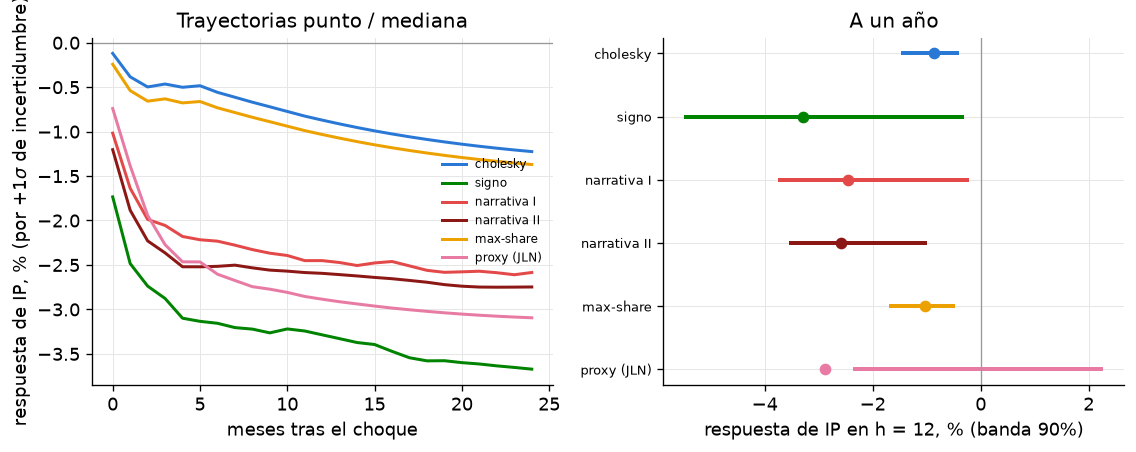

{'cholesky': np.float64(-0.87), 'signo': np.float64(-3.29), 'narrativa I': np.float64(-2.45), 'narrativa II': np.float64(-2.59), 'max-share': np.float64(-1.03), 'proxy (JLN)': np.float64(-2.89)}


In [4]:
COLORS = {"cholesky": "#2a78d6", "signo": "#008300",
          "narrativa I": "#e34948", "narrativa II": "#8c1815",
          "max-share": "#eda100", "proxy (JLN)": "#e87ba4"}
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
hgrid = np.arange(H + 1)
for name, (resp, lo, hi) in runs.items():
    axes[0].plot(hgrid, resp, lw=1.8, color=COLORS[name], label=name)
axes[0].axhline(0, color="0.6", lw=0.8)
axes[0].set_xlabel("meses tras el choque"); axes[0].set_ylabel(
    "respuesta de IP, % (por +1$\\sigma$ de incertidumbre)")
axes[0].set_title("Trayectorias punto / mediana"); axes[0].legend(fontsize=7)

ypos = np.arange(len(runs))[::-1]
for y, (name, (resp, lo, hi)) in zip(ypos, runs.items()):
    c = COLORS[name]
    if lo is not None:
        axes[1].plot([lo[12], hi[12]], [y, y], color=c, lw=2.4,
                     solid_capstyle="butt")
    axes[1].plot(resp[12], y, "o", color=c, ms=6)
axes[1].axvline(0, color="0.6", lw=0.8)
axes[1].set_yticks(ypos); axes[1].set_yticklabels(list(runs), fontsize=8)
axes[1].set_xlabel("respuesta de IP en h = 12, % (banda 90%)")
axes[1].set_title("A un año")
plt.tight_layout(); plt.show()

h12 = {k: v[0][12] for k, v in runs.items()}
print({k: round(v, 2) for k, v in h12.items()})
assert all(v < 0 for v in h12.values()), "las seis respuestas h=12 negativas"

**Leyendo la figura.** Los seis esquemas coinciden en el *signo* — la
producción industrial está más baja un año después de un choque de
incertidumbre — pero la magnitud abarca aproximadamente un factor de
cuatro, y las bandas van de la cinta estrecha de Cholesky (comprada con
el dogma de timing) al ancho conjunto de restricciones de signo (comprado
con honestidad sobre las rotaciones). Las restricciones narrativas
aprietan el conjunto de signo desde dentro; la restricción de dominancia
Tipo II lo aprieta más y lo *repondera* — su ESS queda muy por debajo de
su conteo de aceptadas, y ese es el diagnóstico que te dice que la
restricción es genuinamente informativa y no redundante.

**El remate de la curva de especificaciones.** Este notebook fija los
datos y mueve el supuesto. El pipeline de investigación lo mueve *todo*:
207 celdas estimadas en 12 esquemas × 4 proxies × 3 muestras × 2
detrendings. En esa malla, las dummies de esquema explican R² = 0.24
de la variación en respuestas pico y las dimensiones de datos R² =
0.38 — la elección de identificación rivaliza con la elección de
datos, y toda familia de esquemas con restricciones *económicas*
encuentra un pico negativo. Cuando un paper reporte "el" efecto de la
incertidumbre, pregunta en qué celda de esta malla vive.

## Tu turno — elige tu propia historia

Los cuatro meses de eventos son en sí mismos una elección de
especificación (el pipeline barre todas las configuraciones
leave-one-out; `event_sweep.csv`). Elige tu propio conjunto de eventos:
quita el que te parezca menos un choque *de incertidumbre*, o añade
"2011-08-01" (el impasse del techo de deuda de EE.UU.) — un mes sobre el
que la literatura discute.

In [5]:
# ← Cambia esto: ¿en qué meses fue POSITIVO el choque de incertidumbre?
EVENTS_TRY = ["1987-10-01", "2008-09-01", "2020-03-01"]

r_try = narrative_sign_svar(Y, p=P, horizon=H, sign_matrix=SIGN_PATTERN,
                            restrictions=[(ev, 0, +1) for ev in EVENTS_TRY],
                            dates=dates, n_draws=600, ci=CI, seed=42)
resp_t, lo_t, hi_t = unit_effect(
    r_try.irf_median[0, 0, 0], r_try.irf_median[:, 1, 0],
    r_try.irf_lower[:, 1, 0], r_try.irf_upper[:, 1, 0])
print(f"eventos={[e[:7] for e in EVENTS_TRY]}  ->  h12 = {resp_t[12]:+.2f} "
      f"[{lo_t[12]:+.2f}, {hi_t[12]:+.2f}], ancho {hi_t[12] - lo_t[12]:.2f}, "
      f"{r_try.n_narrative_accepted}/{r_try.n_traditional_accepted} sobreviven")
assert r_try.n_narrative_accepted > 0, "el conjunto de eventos mató todas las rotaciones"

eventos=['1987-10', '2008-09', '2020-03']  ->  h12 = -2.45 [-3.76, -0.22], ancho 3.54, 127/159 sobreviven


**Ejercicios.** (1) *Básico*: corre `EVENTS_TRY` con cada evento por
separado. ¿Cuál aprieta más la banda de h = 12, y por qué un mes donde el
choque fue *inequívoco* es más informativo que un mes famoso? (2)
*Intermedio*: cambia la restricción de Tipo II de arriba a
`dominance="overwhelming"` (Tipo III de AD-RR) solo en COVID. ¿Qué pasa
con el conteo de aceptadas y con el ESS, y qué te dice ese trade-off
sobre cuánta historia puedes imponer antes de que el conjunto quede
vacío? (3) *Reto*: la F del esquema proxy de arriba es respetable, pero
el pipeline encuentra F ≈ 1–2 para algunos pares de proxies — vuelve a
correr el bloque proxy con `wui` como instrumento y explica, con la
lógica de instrumentos débiles del notebook 14, por qué una trayectoria
negativa de aspecto contundente salida de un instrumento débil no debería
tranquilizarte.

**¿Qué tan completo es esto?** El menú de aquí son seis de los doce del
pipeline: `puremacro.var.identify` también incluye largo plazo de
Blanchard-Quah, heteroscedasticidad de Rigobon, quiebres de varianza de
Magnusson-Mavroeidis, ICA no gaussiana e identificación signo-cero, más
las bandas robust-Bayes de Giacomini-Kitagawa (`gk_robust_bands`) para
separar lo que dicen los datos de lo que dice la prior sobre rotaciones;
`puremacro.inference.spec_curve` alimenta la malla completa; y el
notebook 11 construye el lado del *corpus* narrativo que entrega objetos
`NarrativeEvent` directamente a `narrative_sign_svar`.